# Búsqueda semántica con embeddings

Este cuaderno organiza el flujo de trabajo para construir un buscador semántico:

1. Carga de datos
2. Preprocesamiento
3. Generación de embeddings
4. Búsqueda y evaluación
5. Visualización (PCA)

---


In [30]:
from pathlib import Path
import pandas as pd
import unicodedata
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [31]:
# Descargar recursos de NLTK
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

True

## 1. Carga de datos
Cargar los CSV del corpus Rotten Tomatoes y preparar el DataFrame principal.


In [32]:
import pandas as pd
from pathlib import Path

# Cargar los dos CSV del corpus Rotten Tomatoes
path_corpus = Path("data/")

# Cargar movies y reviews
df_movies = pd.read_csv(path_corpus / "rotten_tomatoes_movies.csv")
df_reviews = pd.read_csv(path_corpus / "rotten_tomatoes_critic_reviews.csv")

print(f"Movies: {df_movies.shape}")
print(f"Reviews: {df_reviews.shape}")
df_movies.head(2)

Movies: (17712, 22)
Reviews: (1130017, 8)


,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,...,Sony Pictures Classics,Certified-Fresh,87.0,142.0,Upright,64.0,11574.0,44,123,19


In [33]:
# Merge trayendo más campos útiles
df = df_reviews.merge(
    df_movies[[
        "rotten_tomatoes_link", 
        "movie_title", 
        "genres", 
        "critics_consensus",
        "movie_info"
    ]],
    on="rotten_tomatoes_link",
    how="left"
)

# Construir el texto del documento (título + géneros + reseña)
df["document"] = (
    df["movie_title"].fillna("") + " " +
    df["genres"].fillna("") + " " +
    df["review_content"].fillna("")
).str.strip()


df = df[df["document"] != ""].reset_index(drop=True)

print(f"Total documentos: {len(df)}")

Total documentos: 1129989


In [34]:
df.head(2)

,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content,movie_title,genres,critics_consensus,movie_info,document
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology...,Percy Jackson & the Olympians: The Lightning T...,"Action & Adventure, Comedy, Drama, Science Fic...",Though it may seem like just another Harry Pot...,"Always trouble-prone, the life of teenager Per...",Percy Jackson & the Olympians: The Lightning T...
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiff...",Percy Jackson & the Olympians: The Lightning T...,"Action & Adventure, Comedy, Drama, Science Fic...",Though it may seem like just another Harry Pot...,"Always trouble-prone, the life of teenager Per...",Percy Jackson & the Olympians: The Lightning T...


## 2. Preprocesamiento
Funciones y pasos para limpiar y normalizar los textos antes de generar embeddings.


In [35]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    """
    Preprocesamiento básico para el corpus.
    - Conversión a minúsculas
    - Eliminación de puntuación
    - Eliminación de espacios redundantes
    """
    if not isinstance(text, str):
        return ""
    text = text.lower()                          # minúsculas
    text = re.sub(r"[^\w\s]", "", text)          # eliminar puntuación
    text = re.sub(r"\s+", " ", text).strip()     # espacios redundantes
    
    words = text.split()
    words = [w for w in words if w not in stop_words]
    
    # 6. Lematización
    words = [lemmatizer.lemmatize(w) for w in words]
    
    # 7. Unir de vuelta a string
    return " ".join(words)

In [36]:
# Aplicar preprocesamiento a la columna document
df["document"] = df["document"].apply(preprocess)

df = df.sample(n=5000, random_state=42).reset_index(drop=True)

print(f"Documentos para indexar: {len(df)}")
print(f"\nEjemplo preprocesado:\n{df['document'].iloc[0:10]}")

Documentos para indexar: 5000

Ejemplo preprocesado:
0    joker action adventure drama mystery suspense ...
1    minority report action adventure mystery suspe...
2    teenage mutant ninja turtle action adventure s...
3    blackhat action adventure drama final predicta...
4    safe drama special interest romance there theo...
5    american pop animation drama musical performin...
6    land dead action adventure drama horror myster...
7    whale tale documentary whale tale great specta...
8    piano tuner earthquake art house international...
9    slaughter rule drama gosling morse give strong...
Name: document, dtype: str


## 3. Generación de embeddings

In [37]:
from sentence_transformers import SentenceTransformer
import numpy as np

# 1. Cargar modelo preentrenado
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# 2. Lista de documentos preprocesados
documents = df["document"].tolist()

# 3. Generar embeddings
print("Calculando embeddings...")
embeddings = model.encode(documents, batch_size=120, show_progress_bar=True)
embeddings = np.array(embeddings)

print(f"Shape de embeddings: {embeddings.shape}")

# 4. Guardar en disco para no recalcular
np.save("embeddings_minilm.npy", embeddings)
print("Embeddings guardados en embeddings_minilm.npy")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5218.12it/s]


Calculando embeddings...


Batches: 100%|██████████| 42/42 [01:00<00:00,  1.45s/it]

Shape de embeddings: (5000, 384)
Embeddings guardados en embeddings_minilm.npy


## 4. Búsqueda y evaluación
Funciones para buscar con embeddings y evaluar resultados con consultas de ejemplo.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def search(query, k=5):
    """
    Recupera los k documentos más relevantes para una consulta.
    """
    # Preprocesar la consulta
    query_processed = preprocess(query)
    
    # Generar embedding de la consulta
    query_embedding = model.encode([query_processed])
    
    # Calcular similitud coseno
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    
    #  Top-k índices
    top_k_idx = similarities.argsort()[::-1][:k]
    
    # Construir resultados
    results = []
    for rank, idx in enumerate(top_k_idx, start=1):
        results.append({
            "Ranking":   rank,
            "ID":        df["rotten_tomatoes_link"].iloc[idx],
            "Título":    df["movie_title"].iloc[idx],
            "Fragmento": str(df["review_content"].iloc[idx])[:200],  # ✅ fix
            "Similitud": round(float(similarities[idx]), 4)
        })
    
    return pd.DataFrame(results)

In [39]:
queries = {
    "Q1": "science fiction movie with advanced technology",
    "Q2": "romantic story with emotional relationships",
    "Q3": "action movie with intense fight scenes",
    "Q4": "horror film that creates fear and suspense",
    "Q5": "visually impressive movie with weak storyline",
    "Q6": "emotionally moving performance by the lead actor",
    "Q7": "predictable plot but entertaining experience",
    "Q8": "movie praised by critics but unpopular with audiences"
}

# Ejecutar y mostrar resultados por consulta
resultados_top1 = []

for qid, query in queries.items():
    print(f"\n{'='*60}")
    print(f"{qid}: {query}")
    print('='*60)
    
    results = search(query, k=5)
    display(results)
    
    # Guardar top-1 para tabla resumen
    resultados_top1.append({
        "Consulta":        f"{qid}: {query}",
        "Doc Top-1":       results.iloc[0]["ID"],
        "Título":          results.iloc[0]["Título"],
        "Similitud":       results.iloc[0]["Similitud"]
    })


Q1: science fiction movie with advanced technology


,Ranking,ID,Título,Fragmento,Similitud
0,1,m/eternal_sunshine_of_the_spotless_mind,Eternal Sunshine of the Spotless Mind,This is quite probably the best new science fi...,0.5705
1,2,m/back_to_the_future_2,Back to the Future Part II,nan,0.5646
2,3,m/babylon_ad,Babylon A.D.,Fairly terrible techno-punk action flick.,0.5314
3,4,m/star_wars_the_last_jedi,Star Wars: The Last Jedi,The thing that makes the film most interesting...,0.5233
4,5,m/rocketman_1997,RocketMan,nan,0.5187



Q2: romantic story with emotional relationships


,Ranking,ID,Título,Fragmento,Similitud
0,1,m/the_promise_2017,The Promise,"A clichd, unpersuasive romantic triangle.",0.6133
1,2,m/the-romantics,The Romantics,nan,0.6117
2,3,m/vita_and_virginia,Vita & Virginia,This peek into a famous love story makes the a...,0.5799
3,4,m/1084607-at_first_sight,At First Sight,nan,0.5797
4,5,m/crazy-beautiful,Crazy/Beautiful,nan,0.5747



Q3: action movie with intense fight scenes


...

,Ranking,ID,Título,Fragmento,Similitud
0,1,m/rush_2013,Rush,Exhilarating in parts and immensely moving in ...,0.5347
1,2,m/journeys_end_2018,Journey's End,Director Saul Dibb doesn't quite succeed in ma...,0.4995
2,3,m/stronger_2017,Stronger,"It's still inspirational, but does a better jo...",0.4866
3,4,m/step_up,Step Up,...concentrates less on the odd-couple idiosyn...,0.4864
4,5,m/the_perks_of_being_a_wallflower,The Perks of Being a Wallflower,"Charlie's personality relaxes yet moves you, a...",0.4760



Q7: predictable plot but entertaining experience


,Ranking,ID,Título,Fragmento,Similitud
0,1,m/clue,Clue,goofy and entertaining,0.5771
1,2,m/spotlight_2015,Spotlight,Capably and decently tells an important story.,0.5755
2,3,m/deja_vu,Déjà Vu,This slight variation on the time travel theme...,0.5728
3,4,m/hereafter,Hereafter,"Coincidences and improbabilities aside, the sc...",0.5637
4,5,m/mrs_henderson_presents,Mrs. Henderson Presents,... perfectly pleasant and exceedingly predict...,0.5617



Q8: movie praised by critics but unpopular with audiences


,Ranking,ID,Título,Fragmento,Similitud
0,1,m/movie_43,Movie 43,"As a film critic, I've seen nearly 4,000 movie...",0.4863
1,2,m/scary_movie_2,Scary Movie 2,This is the most damning criticism that could ...,0.4807
2,3,m/revolutionary_road,Revolutionary Road,Somehow the film fails to inspire more than ad...,0.4754
3,4,m/the_way_back,The Way Back,full review at Movies for the Masses,0.4605
4,5,m/tv_set,The TV Set,if Kasdan's point was to use the film as metap...,0.4548


In [40]:
print("\n" + "="*60)
print("TABLA RESUMEN GENERAL")
print("="*60)

df_resumen = pd.DataFrame(resultados_top1)
display(df_resumen)


TABLA RESUMEN GENERAL


,Consulta,Doc Top-1,Título,Similitud
0,Q1: science fiction movie with advanced techno...,m/eternal_sunshine_of_the_spotless_mind,Eternal Sunshine of the Spotless Mind,0.5705
1,Q2: romantic story with emotional relationships,m/the_promise_2017,The Promise,0.6133
2,Q3: action movie with intense fight scenes,m/1207523-obsessed,Obsessed,0.6768
3,Q4: horror film that creates fear and suspense,m/dont_be_afraid_of_the_dark_2011,Don't Be Afraid Of The Dark,0.7893
4,Q5: visually impressive movie with weak storyline,m/transcendence_2014,Transcendence,0.6020
5,Q6: emotionally moving performance by the lead...,m/rush_2013,Rush,0.5347
6,Q7: predictable plot but entertaining experience,m/clue,Clue,0.5771
7,Q8: movie praised by critics but unpopular wit...,m/movie_43,Movie 43,0.4863


## 5. Visualización PCA
Aplicar PCA sobre los embeddings y visualizar en 2D. Incluir consultas de ejemplo en el mismo espacio.


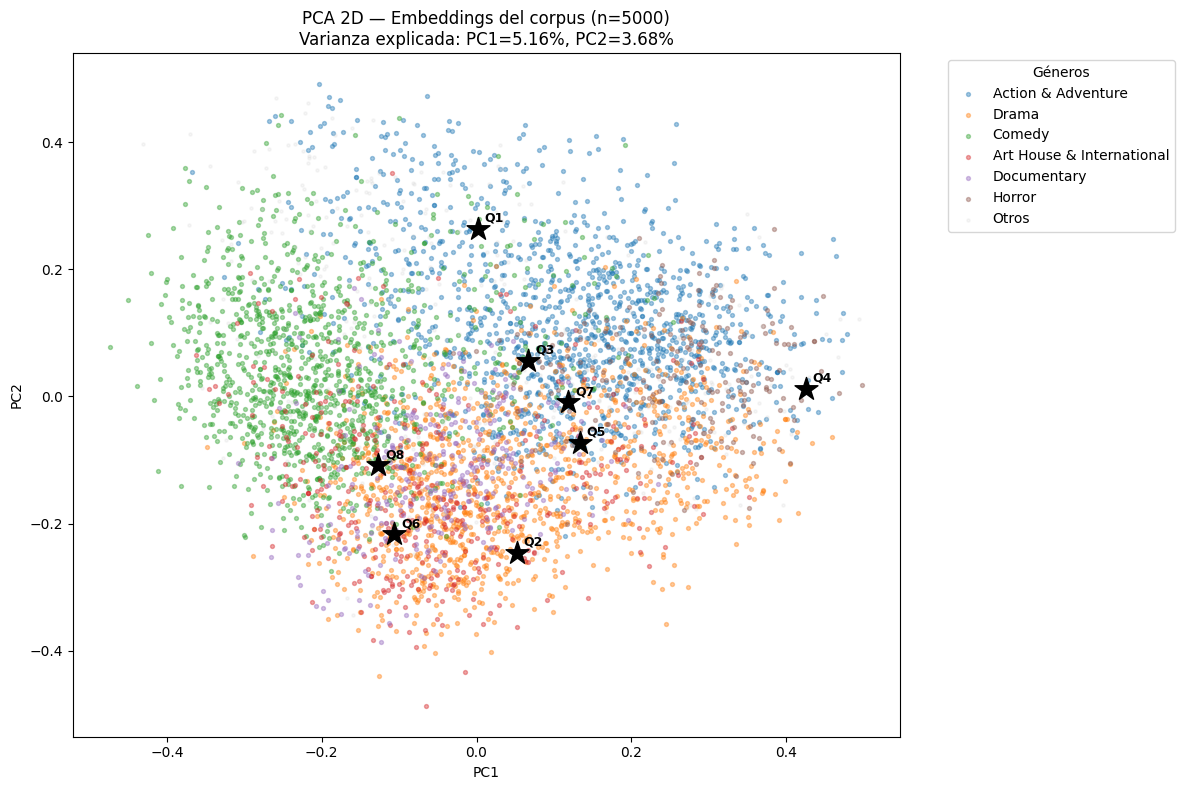

Varianza explicada total: 8.83%


In [42]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Cargar embeddings
emb = np.load("embeddings_minilm.npy")

# Sample
sample = 5000
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(emb), size=sample, replace=False)
emb_sample = emb[sample_idx]

# Géneros de la muestra
labels_sample = df["genres"].fillna("Unknown").iloc[sample_idx].apply(
    lambda x: x.split(",")[0].strip()
)
top_genres = labels_sample.value_counts().head(6).index
colors = plt.cm.tab10.colors

# PCA
pca = PCA(n_components=2, random_state=0)
X = pca.fit_transform(emb_sample)

# Embeddings de las 8 consultas
queries_processed = [preprocess(q) for q in queries.values()]
q_emb = model.encode(queries_processed)
q_2d = pca.transform(q_emb)

# Graficar
plt.figure(figsize=(12, 8))

# Documentos por género
for i, genre in enumerate(top_genres):
    mask = labels_sample == genre
    plt.scatter(X[mask, 0], X[mask, 1],
                label=genre, alpha=0.4, s=8, color=colors[i])

# Resto sin género top
mask_other = ~labels_sample.isin(top_genres)
plt.scatter(X[mask_other, 0], X[mask_other, 1],
            alpha=0.2, s=5, color="lightgray", label="Otros")

# Consultas del benchmark
for (qid, _), point in zip(queries.items(), q_2d):
    plt.scatter(point[0], point[1], marker="*", s=300, color="black", zorder=5)
    plt.annotate(qid, (point[0], point[1]),
                 fontsize=9, fontweight="bold",
                 xytext=(5, 5), textcoords="offset points")

plt.title(f"PCA 2D — Embeddings del corpus (n={sample})\n"
          f"Varianza explicada: PC1={pca.explained_variance_ratio_[0]:.2%}, "
          f"PC2={pca.explained_variance_ratio_[1]:.2%}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Géneros", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("pca_embeddings.png", dpi=150)
plt.show()

print(f"Varianza explicada total: {pca.explained_variance_ratio_.sum():.2%}")